# Analysis

In [76]:
import json
import numpy as np

#load JSON data from a file
#file = "/Users/tobi/Documents/Projekte/Show2Instruct/bim-benchmark/results/run_2026-01-21_16-52-25/cache_gpt-5.2.json"
#file = "/Users/tobi/Documents/Projekte/Show2Instruct/bim-benchmark/results/run_2026-01-22_09-36-56/cache_gpt-5.2.json"
#file = "/Users/tobi/Documents/Projekte/Show2Instruct/bim-benchmark/results/run_2026-01-22_12-53-56/cache_gpt-5.2.json"
#file = "/Users/tobi/Documents/Projekte/Show2Instruct/bim-benchmark/results/run_2026-01-22_12-53-56/cache_gpt-5.2.json"
file = "/Users/tobi/Documents/Projekte/Show2Instruct/bim-benchmark/results/run_2026-01-22_12-53-56/cache_reeval.json"
with open(file, 'r') as f:
    data = json.load(f)

metrics = set()
scores = []
it = 0
score_per_group = []
score_gp = []
for key in data.keys():
    if it % 5 == 0:
        if it != 0:
            score_per_group.append(np.mean(score_gp))
            score_gp = []
    metrics.update(data[key]["results"][0]["metrics"].keys())
    scores.append(data[key]["results"][0]["score"])
    score_gp.append(data[key]["results"][0]["score"])
    it += 1
score_per_group.append(np.mean(score_gp))


In [77]:
np.mean(scores)

0.28916666666666674

In [78]:
# read questions.csv
import pandas as pd
questions_file = "/Users/tobi/Documents/Projekte/Show2Instruct/bim-benchmark/data/all_questions.csv"
questions_df = pd.read_csv(questions_file)

#remove rows with ",,,,"
mask = questions_df['question'].astype(str).str.contains(',,,,')
questions_df = questions_df[~mask]
questions_df = questions_df.dropna(subset=["question"])
questions_df["scores"] = scores

types = np.repeat(["basic", "geometry", "topology", "numeric", "conceptual"], 20)

questions_df["type"] = types

questions_df["solved"] = (questions_df["scores"] == 1).astype(int)

In [79]:
# mean score by type
mean_by_type = questions_df.groupby("type")["scores"].mean()
print(mean_by_type)

# mean score by CRUD (assuming the column is named "CRUD")
mean_by_crud = questions_df.groupby("CRUD")["scores"].mean()
print(mean_by_crud)

type
basic         0.487500
conceptual    0.050000
geometry      0.508333
numeric       0.050000
topology      0.350000
Name: scores, dtype: float64
CRUD
create      0.650000
delete      0.433333
retrieve    0.145455
update      0.311111
Name: scores, dtype: float64


In [80]:
# mean solved rate by type
solved_by_type = questions_df.groupby("type")["solved"].mean()
print(solved_by_type)

# mean solved rate by CRUD (adjust column name if needed)
solved_by_crud = questions_df.groupby("CRUD")["solved"].mean()
print(solved_by_crud)

type
basic         0.30
conceptual    0.05
geometry      0.40
numeric       0.05
topology      0.15
Name: solved, dtype: float64
CRUD
create      0.266667
delete      0.266667
retrieve    0.145455
update      0.200000
Name: solved, dtype: float64


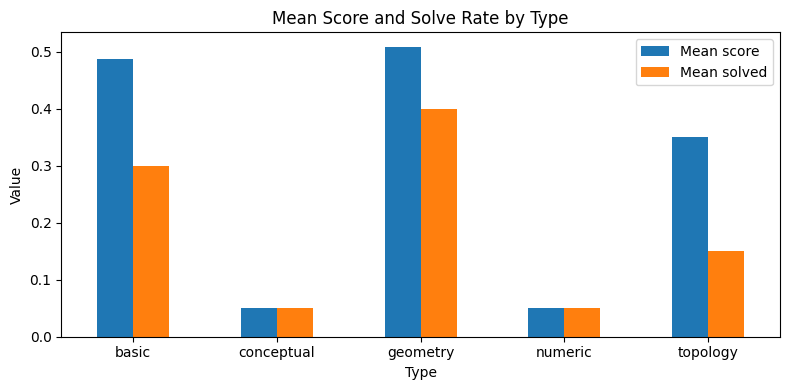

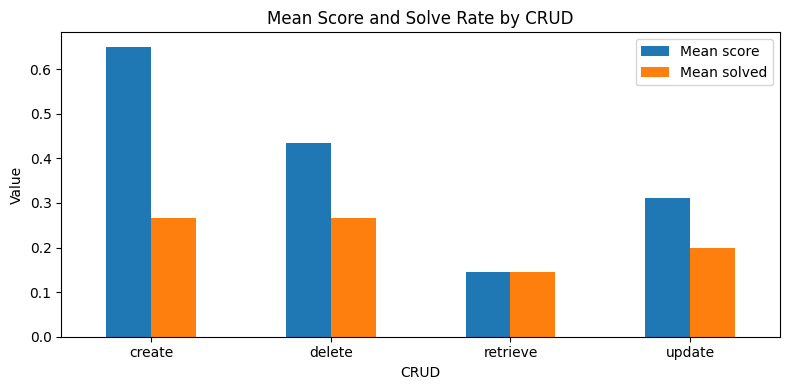

In [81]:
import matplotlib.pyplot as plt

# --- by Type: mean score + mean solved ---
type_summary = (
    questions_df.groupby("type")
    .agg(mean_score=("scores", "mean"), mean_solved=("solved", "mean"))
)

ax = type_summary.plot(kind="bar", figsize=(8, 4))
ax.set_title("Mean Score and Solve Rate by Type")
ax.set_xlabel("Type")
ax.set_ylabel("Value")
ax.legend(["Mean score", "Mean solved"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --- by CRUD: mean score + mean solved ---
crud_col = "CRUD" if "CRUD" in questions_df.columns else "category"

crud_summary = (
    questions_df.groupby(crud_col)
    .agg(mean_score=("scores", "mean"), mean_solved=("solved", "mean"))
)

ax = crud_summary.plot(kind="bar", figsize=(8, 4))
ax.set_title(f"Mean Score and Solve Rate by {crud_col}")
ax.set_xlabel(crud_col)
ax.set_ylabel("Value")
ax.legend(["Mean score", "Mean solved"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tool Use

In [82]:
from collections import Counter

def count_tool_calls(data):
    counter = Counter()

    for entry in data.values():
        iterations = entry.get("results", [{}])[0].get("tool_call_iterations", [])
        for iteration in iterations:
            for call in iteration.get("tool_calls", []):
                name = call.get("name")
                if name:
                    counter[name] += 1

    return dict(counter)

tool_call_counts = count_tool_calls(data)

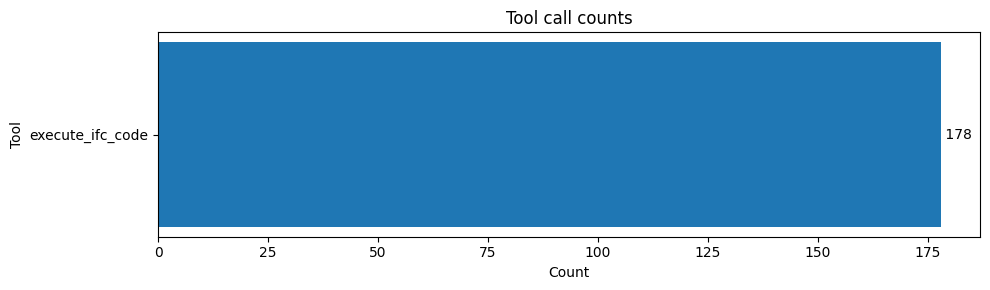

In [83]:
counts = pd.Series(tool_call_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(counts))))
ax.barh(counts.index, counts.values)

ax.set_title("Tool call counts")
ax.set_xlabel("Count")
ax.set_ylabel("Tool")

# label bars with values
for i, v in enumerate(counts.values):
    ax.text(v, i, f" {int(v)}", va="center")

plt.tight_layout()
plt.show()

In [84]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def norm(x):
    if x is None:
        return None
    return str(x).strip().lower()

# --- 1) build set of successful task ids from the dataframe ---
# change "test" to whatever column matches your data (e.g. "id") if needed
successful_tests = set(
    questions_df.loc[questions_df["scores"] > 0, "test"].map(norm)
)

# --- 2) collect task ids present in `data` (from entry["test"] OR dict key) ---
data_test_ids = set()
for k, entry in data.items():
    data_test_ids.add(norm(entry.get("test", k)))

# --- 3) quick diagnostics ---
intersection = successful_tests & data_test_ids
print("Successful tests:", len(successful_tests))
print("Data tests:", len(data_test_ids))
print("Intersection:", len(intersection))
print("Example successful:", list(successful_tests)[:10])
print("Example data ids:", list(data_test_ids)[:10])

# If intersection is 0, you likely need a different column than "test"
# or your test ids are stored elsewhere inside `entry`.
# You can also inspect one entry:
first_key = next(iter(data))
print("First data key:", first_key)
print("First data entry keys:", list(data[first_key].keys()))

# --- 4) count tool calls only for successful tasks that actually match ---
def count_tool_calls_filtered(data, allowed_tests_norm: set):
    counter = Counter()

    for k, entry in data.items():
        test_id = norm(entry.get("test", k))
        if test_id not in allowed_tests_norm:
            continue

        iterations = entry.get("results", [{}])[0].get("tool_call_iterations", [])
        for iteration in iterations:
            for call in iteration.get("tool_calls", []):
                name = call.get("name")
                if name:
                    counter[name] += 1

    return dict(counter)

tool_call_counts_success = count_tool_calls_filtered(data, successful_tests)

print("Tools counted:", len(tool_call_counts_success))  # should be > 0 now

# --- 5) plot ---
if tool_call_counts_success:
    counts = pd.Series(tool_call_counts_success).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(counts))))
    ax.barh(counts.index, counts.values)
    ax.set_title("Tool call counts (only tasks with score > 0)")
    ax.set_xlabel("Count")
    ax.set_ylabel("Tool")

    for i, v in enumerate(counts.values):
        ax.text(v, i, f" {int(v)}", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("No matching successful tasks found in `data` after normalization.")

Successful tests: 40
Data tests: 100
Intersection: 0
Example successful: ['geometry_test_02', 'test_20', 'test_19', 'topological_test_12', 'topological_test_15', 'geometry_test_11', 'test_08', 'topological_test_06', 'geometry_test_15', 'test_09']
Example data ids: ['47', '98', '31', '81', '43', '33', '48', '18', '66', '15']
First data key: 0
First data entry keys: ['question_id', 'prompt', 'model', 'ifc_file', 'results', 'timestamp']
Tools counted: 0
No matching successful tasks found in `data` after normalization.


Rows merged with question_id: 100 / 100
Allowed qids (score>0): 40
Tools counted: 1


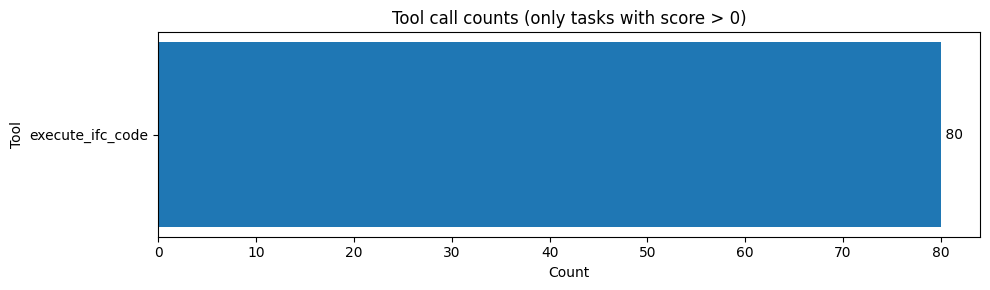

In [85]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def norm_text(s):
    if pd.isna(s):
        return None
    return " ".join(str(s).strip().split())

# --- 1) build mapping dataframe from `data` ---
data_map = pd.DataFrame([
    {
        "question_id": str(entry.get("question_id")).strip(),
        "prompt": norm_text(entry.get("prompt")),
    }
    for entry in data.values()
    if entry.get("prompt") is not None and entry.get("question_id") is not None
])

# --- 2) merge into your questions_df using text match ---
qdf = questions_df.copy()
qdf["question_norm"] = qdf["question"].map(norm_text)

merged = qdf.merge(
    data_map,
    left_on="question_norm",
    right_on="prompt",
    how="left"
)

print("Rows merged with question_id:", merged["question_id"].notna().sum(), "/", len(merged))

# --- 3) allowed question_ids where score > 0 ---
allowed_qids = set(merged.loc[merged["scores"] > 0, "question_id"].dropna().astype(str))

print("Allowed qids (score>0):", len(allowed_qids))

# --- 4) count tool calls only for those qids ---
def count_tool_calls_for_qids(data, allowed_qids: set):
    counter = Counter()
    for entry in data.values():
        qid = entry.get("question_id")
        if qid is None or str(qid).strip() not in allowed_qids:
            continue

        iterations = entry.get("results", [{}])[0].get("tool_call_iterations", [])
        for iteration in iterations:
            for call in iteration.get("tool_calls", []):
                name = call.get("name")
                if name:
                    counter[name] += 1
    return dict(counter)

tool_call_counts_success = count_tool_calls_for_qids(data, allowed_qids)
print("Tools counted:", len(tool_call_counts_success))

# --- 5) plot ---
if tool_call_counts_success:
    counts = pd.Series(tool_call_counts_success).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(counts))))
    ax.barh(counts.index, counts.values)
    ax.set_title("Tool call counts (only tasks with score > 0)")
    ax.set_xlabel("Count")
    ax.set_ylabel("Tool")

    for i, v in enumerate(counts.values):
        ax.text(v, i, f" {int(v)}", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("Still zero. Likely the question text in CSV != prompt text in data (different formatting).")

In [86]:
metrics

{'integrity_constraint',
 'object_exists',
 'object_not_exists',
 'right_answer',
 'right_dimensions',
 'right_location'}

# Performance per Metric

In [87]:
import numpy as np
import pandas as pd

# Build a metrics DataFrame (same as before)
metric_rows = []
qids = []
for key, item in data.items():
    r0 = item["results"][0]
    m = r0.get("metrics", {}) or {}
    metric_rows.append(m)
    qids.append(item.get("question_id", key))

metrics_df = pd.DataFrame(metric_rows, index=qids).sort_index()

# --- Robust coercion to nullable boolean ---
TRUE_SET  = {"true", "t", "1", "yes", "y"}
FALSE_SET = {"false", "f", "0", "no", "n"}

def to_nullable_bool(x):
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    if isinstance(x, (int, np.integer)) and x in (0, 1):
        return bool(x)
    if isinstance(x, (float, np.floating)) and x in (0.0, 1.0):
        return bool(int(x))
    if isinstance(x, str):
        s = x.strip().lower()
        if s in TRUE_SET:
            return True
        if s in FALSE_SET:
            return False
        return pd.NA
    return pd.NA

metrics_df = metrics_df.applymap(to_nullable_bool).astype("boolean")

# 1) Overall metric overview
metric_overview = pd.DataFrame({
    "pass_rate": metrics_df.mean(skipna=True).astype(float),
    "n_true": metrics_df.sum(skipna=True).astype("Int64"),
    "n_total": metrics_df.count(),
    "n_missing": metrics_df.isna().sum(),
}).sort_values("pass_rate", ascending=False)

print("\n=== Metric overview ===")
print(metric_overview)

# (Optional) identify which values were "bad" (not coercible)
bad_mask = metrics_df.isna() & pd.DataFrame(metric_rows, index=qids).notna()
bad_locs = bad_mask.stack()
bad_locs = bad_locs[bad_locs].index.tolist()
if bad_locs:
    print("\nFound non-bool-like metric values at (row, metric):")
    print(bad_locs[:50], "..." if len(bad_locs) > 50 else "")

# 2) Metric pass-rates by type / CRUD
metrics_aligned = metrics_df.reset_index(drop=True)  # assumes same order as questions_df/scores
questions_with_metrics = pd.concat([questions_df.reset_index(drop=True), metrics_aligned], axis=1)

metric_cols = metrics_df.columns.tolist()
by_type = questions_with_metrics.groupby("type")[metric_cols].mean(numeric_only=True)
print("\n=== Metric pass-rate by type ===")
print(by_type)

crud_col = "CRUD" if "CRUD" in questions_with_metrics.columns else "category"
by_crud = questions_with_metrics.groupby(crud_col)[metric_cols].mean(numeric_only=True)
print(f"\n=== Metric pass-rate by {crud_col} ===")
print(by_crud)


=== Metric overview ===
                      pass_rate  n_true  n_total  n_missing
object_exists          1.000000      15       15         85
object_not_exists      0.600000       9       15         85
integrity_constraint   0.476190      20       42         58
right_location         0.433333      13       30         70
right_dimensions       0.300000       9       30         70
right_answer           0.145455       8       55         45

=== Metric pass-rate by type ===
            object_exists  right_location  right_dimensions  \
type                                                          
basic                 1.0             0.2               0.1   
conceptual           <NA>            <NA>              <NA>   
geometry              1.0             0.6               0.6   
numeric              <NA>            <NA>              <NA>   
topology              1.0             0.5               0.2   

            integrity_constraint  right_answer  object_not_exists  
type       

/var/folders/7z/lcc90j2d4118v85w_05_h9fr0000gn/T/ipykernel_7937/1203013199.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  metrics_df = metrics_df.applymap(to_nullable_bool).astype("boolean")


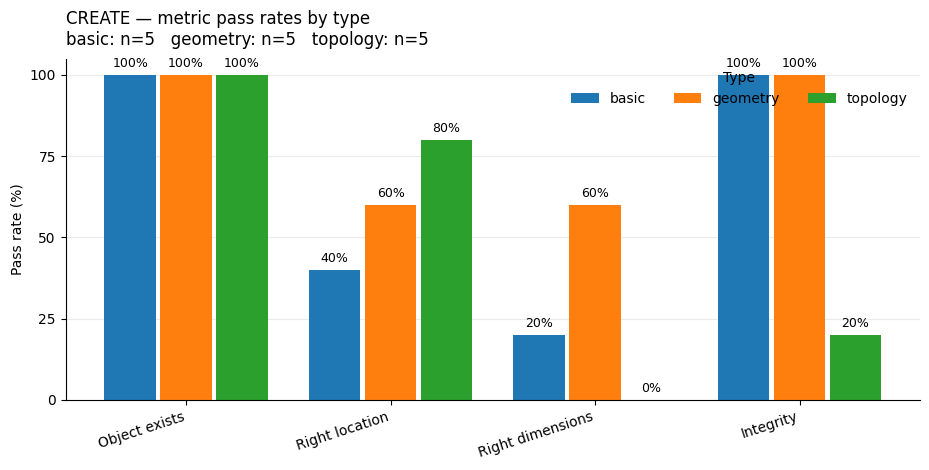

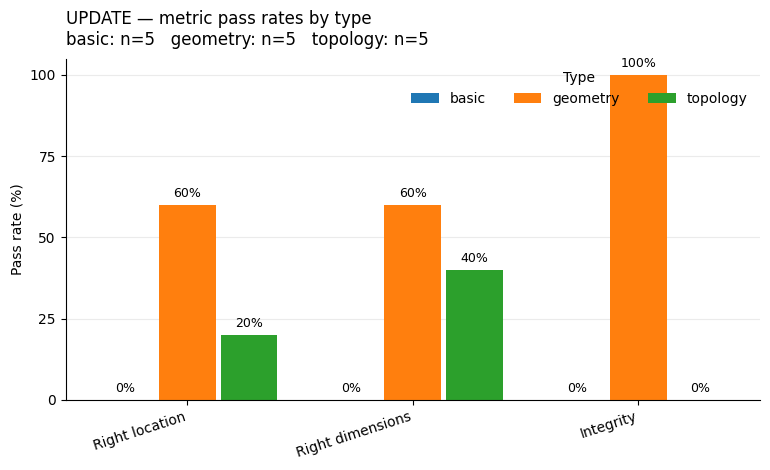

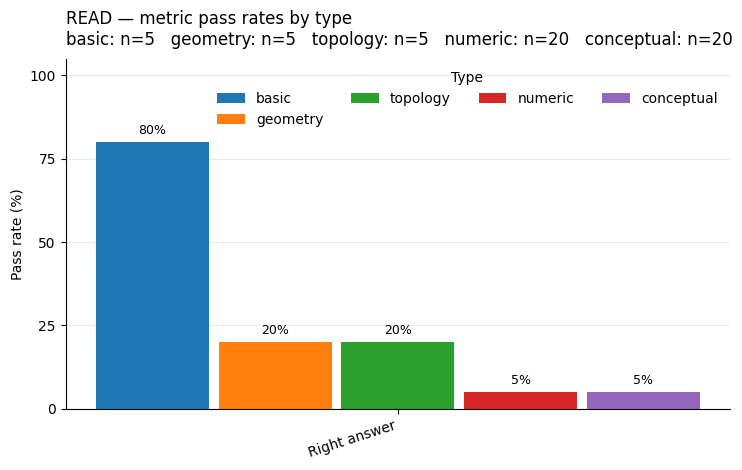

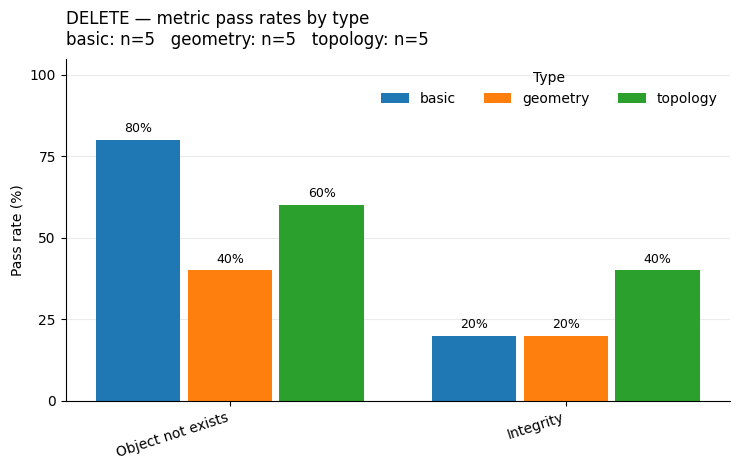

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config: which metrics apply to which CRUD
# -----------------------------
EXPECTED = {
    "CREATE": ["object_exists", "right_location", "right_dimensions", "integrity_constraint"],
    "UPDATE": ["right_location", "right_dimensions", "integrity_constraint"],
    "READ":   ["right_answer"],
    "DELETE": ["object_not_exists", "integrity_constraint"],
}

# -----------------------------
# Helpers
# -----------------------------
def normalize_crud(x):
    if pd.isna(x):
        return x
    s = str(x).strip().upper()
    if s.startswith("C"): return "CREATE"
    if s.startswith("U"): return "UPDATE"
    if s.startswith("R"): return "READ"
    if s.startswith("D"): return "DELETE"
    return s

def passrate(series_bool):
    s = series_bool.astype("Float64")  # True->1, False->0, NA->NA
    return float(s.mean(skipna=True)) if s.count() > 0 else np.nan

def pretty_metric_name(m):
    return {
        "object_exists": "Object exists",
        "object_not_exists": "Object not exists",
        "right_location": "Right location",
        "right_dimensions": "Right dimensions",
        "integrity_constraint": "Integrity",
        "right_answer": "Right answer",
    }.get(m, m)

def plot_crud_grouped_bars(
    df,
    crud_name,
    crud_col="CRUD",
    type_col="type",
    type_order=("basic", "geometry", "topology", "numeric"),
    show_percent=True,
    annotate=True,
):
    metrics = EXPECTED[crud_name]
    sub = df[df[crud_col] == crud_name].copy()

    # Types present (stable order)
    types_present = [t for t in type_order if t in set(sub[type_col].dropna())]
    if not types_present:
        types_present = sorted(sub[type_col].dropna().unique().tolist())

    # Build table (rows=type, cols=metrics)
    table = pd.DataFrame(index=types_present, columns=metrics, dtype=float)
    n_table = pd.DataFrame(index=types_present, columns=metrics, dtype=float)

    for t in types_present:
        st = sub[sub[type_col] == t]
        for m in metrics:
            n_table.loc[t, m] = st[m].count()
            table.loc[t, m] = passrate(st[m])

    # Convert to percent if desired
    plot_table = table * 100.0 if show_percent else table

    # ----- Figure / axes styling (cleaner defaults, no manual colors) -----
    n_metrics = len(metrics)
    fig_w = max(7.5, 1.6 * n_metrics + 3.0)
    fig_h = 4.8
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    x = np.arange(n_metrics)
    k = len(types_present)
    group_w = 0.82
    bar_w = group_w / max(k, 1)

    # Bars
    for i, t in enumerate(types_present):
        vals = plot_table.loc[t].to_numpy(dtype=float)
        heights = np.nan_to_num(vals, nan=0.0)

        # center groups around x
        offsets = (i - (k - 1) / 2) * bar_w
        bars = ax.bar(x + offsets, heights, width=bar_w * 0.92, label=str(t))

        # Value labels (skip N/A)
        if annotate:
            for j, v in enumerate(vals):
                if np.isfinite(v):
                    ax.text(
                        x[j] + offsets,
                        v + (1.5 if show_percent else 0.02),
                        f"{v:.0f}%" if show_percent else f"{v:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=9,
                    )

    # Axes labels
    xticklabels = [pretty_metric_name(m) for m in metrics]
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, rotation=18, ha="right")

    if show_percent:
        ax.set_ylim(0, 105)
        ax.set_ylabel("Pass rate (%)")
        ax.set_yticks([0, 25, 50, 75, 100])
    else:
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Pass rate")

    # Title + subtitle with sample sizes
    total_n = len(sub)
    by_type_n = sub.groupby(type_col).size().reindex(types_present).fillna(0).astype(int)
    subtitle = "   ".join([f"{t}: n={by_type_n.loc[t]}" for t in types_present])
    ax.set_title(f"{crud_name} — metric pass rates by type\n{subtitle}", loc="left", pad=10)

    # Grid and spines (minimal)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    ax.legend(title="Type", frameon=False, ncol=min(4, len(types_present)), loc="upper right")

    plt.tight_layout()
    return fig, ax, table, n_table


# -----------------------------
# Usage: assumes you already have questions_with_metrics with:
# - a CRUD column (crud_col) and a type column ("type")
# - metric columns as booleans (pandas nullable boolean ok)
# -----------------------------

# If needed, normalize CRUD labels:
crud_col = "CRUD" if "CRUD" in questions_with_metrics.columns else "category"
questions_with_metrics[crud_col] = questions_with_metrics[crud_col].apply(normalize_crud)

# Ensure all expected metric columns exist (missing -> NA)
all_metrics = sorted({m for ms in EXPECTED.values() for m in ms})
for m in all_metrics:
    if m not in questions_with_metrics.columns:
        questions_with_metrics[m] = pd.NA

# Plot one figure per CRUD
for crud_name in ["CREATE", "UPDATE", "READ", "DELETE"]:
    fig, ax, table, n_table = plot_crud_grouped_bars(
        questions_with_metrics,
        crud_name,
        crud_col=crud_col,
        type_col="type",
        type_order=("basic", "geometry", "topology", "numeric", "conceptual"),
        show_percent=True,
        annotate=True,
    )
    plt.show()

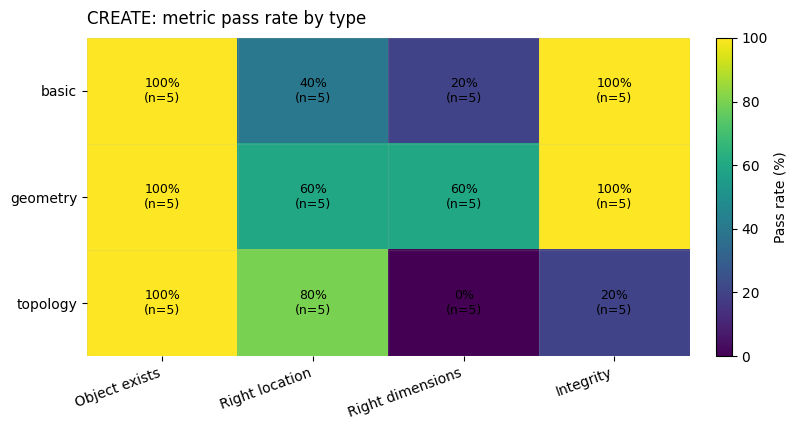

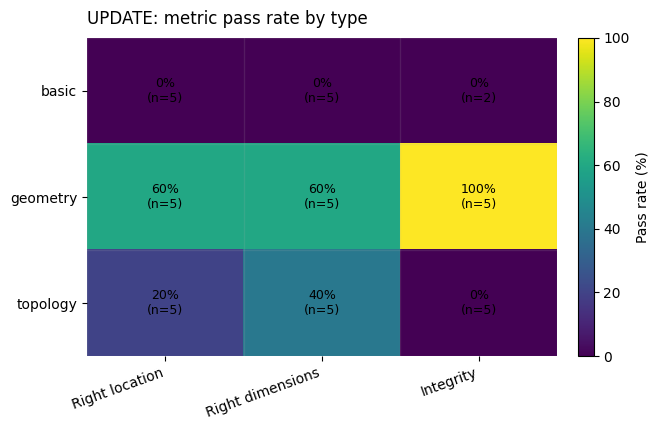

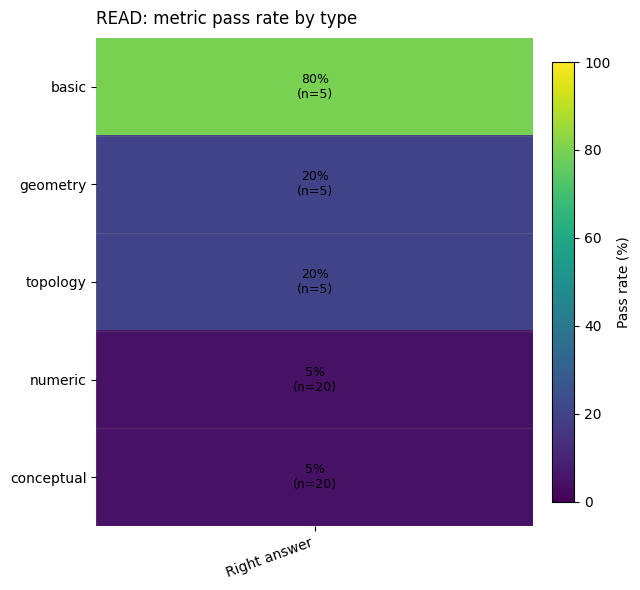

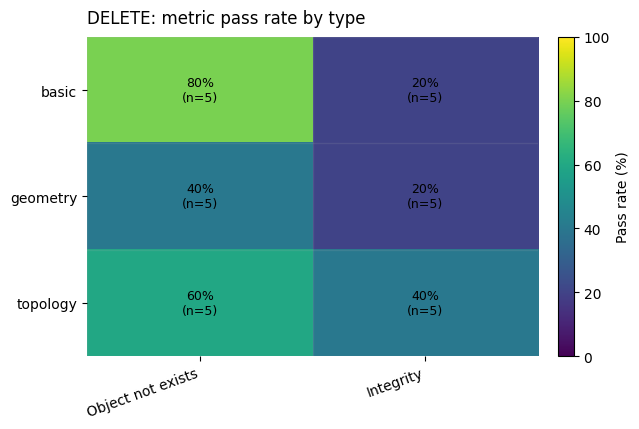

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPECTED = {
    "CREATE": ["object_exists", "right_location", "right_dimensions", "integrity_constraint"],
    "UPDATE": ["right_location", "right_dimensions", "integrity_constraint"],
    "READ":   ["right_answer"],
    "DELETE": ["object_not_exists", "integrity_constraint"],
}

def normalize_crud(x):
    if pd.isna(x):
        return x
    s = str(x).strip().upper()
    if s.startswith("C"): return "CREATE"
    if s.startswith("U"): return "UPDATE"
    if s.startswith("R"): return "READ"
    if s.startswith("D"): return "DELETE"
    return s

def pretty_metric(m):
    return {
        "object_exists": "Object exists",
        "object_not_exists": "Object not exists",
        "right_location": "Right location",
        "right_dimensions": "Right dimensions",
        "integrity_constraint": "Integrity",
        "right_answer": "Right answer",
    }.get(m, m)

def passrate(s):
    s = s.astype("Float64")  # True->1 False->0 NA->NA
    return float(s.mean(skipna=True)) if s.count() else np.nan

def compute_type_x_metric(df, crud_name, crud_col="CRUD", type_col="type", type_order=None):
    metrics = EXPECTED[crud_name]
    sub = df[df[crud_col] == crud_name].copy()

    if type_order is None:
        types = sorted(sub[type_col].dropna().unique().tolist())
    else:
        types = [t for t in type_order if t in set(sub[type_col].dropna())]

    rates = pd.DataFrame(index=types, columns=metrics, dtype=float)
    counts = pd.DataFrame(index=types, columns=metrics, dtype=float)

    for t in types:
        st = sub[sub[type_col] == t]
        for m in metrics:
            counts.loc[t, m] = st[m].count()
            rates.loc[t, m] = passrate(st[m])

    return rates, counts

def plot_heatmap_per_crud(rates, counts, title):
    # rates in [0,1], can have NaN
    Z = rates.to_numpy(dtype=float) * 100.0  # percent
    nrows, ncols = Z.shape

    # Figure size scales with content
    fig_w = max(6.5, 1.4 * ncols + 2.5)
    fig_h = max(3.8, 0.8 * nrows + 2.0)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(Z, vmin=0, vmax=100, aspect="auto")

    # Ticks/labels
    ax.set_yticks(np.arange(nrows))
    ax.set_yticklabels(rates.index.astype(str))
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels([pretty_metric(c) for c in rates.columns], rotation=20, ha="right")

    # Title
    ax.set_title(title, loc="left", pad=10)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pass rate (%)")

    # Cell annotations: value + n
    for i in range(nrows):
        for j in range(ncols):
            v = Z[i, j]
            n = counts.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.0f}%\n(n={int(n)})", ha="center", va="center", fontsize=9)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=12, alpha=0.6)

    # Subtle grid lines between cells
    ax.set_xticks(np.arange(-.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, nrows, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, alpha=0.15)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Clean spines
    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)

    plt.tight_layout()
    return fig, ax

# --- Usage: assumes questions_with_metrics exists (questions_df + metrics_df merged) ---
crud_col = "CRUD" if "CRUD" in questions_with_metrics.columns else "category"
questions_with_metrics[crud_col] = questions_with_metrics[crud_col].apply(normalize_crud)

# Ensure expected metric columns exist
for m in sorted({x for xs in EXPECTED.values() for x in xs}):
    if m not in questions_with_metrics.columns:
        questions_with_metrics[m] = pd.NA

type_order = ("basic", "geometry", "topology", "numeric", "conceptual")

for crud_name in ["CREATE", "UPDATE", "READ", "DELETE"]:
    rates, counts = compute_type_x_metric(
        questions_with_metrics, crud_name, crud_col=crud_col, type_col="type", type_order=type_order
    )
    plot_heatmap_per_crud(rates, counts, f"{crud_name}: metric pass rate by type")
    plt.show()